<img src="images/purple_net.jpeg" alt="purple_net"> 

# **<font color="purple">DNN Regression -- Lab 5 </font>**
### **<font color="purple">Prof. Tiziana Ligorio</font>**
### **<font color="purple">Hunter College of The City University of New York</font>**

---
---

In [ ]:
!pip install lightning torchinfo -q

# Make a copy of this notebook in your drive so you can edit it

In this tutorial we will revisit the [California Housing Prices Dataset](https://www.kaggle.com/camnugent/california-housing-prices) to train a Deep Neural Network using **PyTorch** and **PyTorch Lightning**.

We will do the following:
1. [Partition the data into Training, Validation and Test set](#partition)
2. [Data Preprocessing](#preprocessing)
3. [Select and Train the Model](#model)
    * [A First Attempt: The Naive Deep Network](#naive)
    * [The DNN Toolbox](#toolbox)
      * [Weight Initialization](#weight_init)
      * [Activation Functions](#activation)
      * [Batch Normalization](#bn)
      * [Gradient Clipping](#gc)
      * [Faster Optimizers](#optimizers)
      * [Learning Rate Schedules](#schedules)
      * [Regularization](#regularization)
    * [Gradient Clipping in Action](#gc_demo)
    * [Putting It All Together](#full_stack)
4. [Evaluate the Model](#evaluate)

<a id="partition"></a>
# Partition into Training and Test set
---

In [1]:
# import the packages we will use
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn
import tarfile

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger

from sklearn.metrics import mean_squared_error
from scipy import stats

In previous labs we have set the seed to try and generate reproducible results. With PyTorch, we set both the NumPy seed and the PyTorch seed. Note that full reproducibility on GPU is not always guaranteed due to non-deterministic CUDA operations.

In [2]:
# set random seeds for reproducibility
np.random.seed(15)
torch.manual_seed(15)
L.seed_everything(15, workers=True)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(15)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Seed set to 15


Using device: cpu


In [3]:
# load the data
!wget https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz
!ls #list the files

--2026-03-17 22:28:52--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.tgz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 409488 (400K) [application/octet-stream]
Saving to: ‘housing.tgz.3’

housing.tgz.3       100%[===================>] 399,89K  --.-KB/s    in 0,1s    

2026-03-17 22:28:53 (3,43 MB/s) - ‘housing.tgz.3’ saved [409488/409488]

Lab1_Train_Test_Evaluate.ipynb
Lab2_Perceptron_torch.ipynb
Lab3_ANN-Classification_MatrixMultiplication_torch.ipynb
Lab4OLD_ANN-Images_torch.ipynb
Lab4_ANN-Images_torch.ipynb
Lab6-DNN-Regression_torch.ipynb
Lab6OLD-DNN-Regression_torch copy.ipynb
README.md
checkpoints
data
housing.csv
housing.tgz
housing.tgz.1
housing.tgz.2
housing.tgz.3
images
lightning_logs
spirals.csv


In [4]:
# extract the .tgz file
tar = tarfile.open("housing.tgz")
tar.extractall()
tar.close()

/var/folders/64/wb5ckbx51jzbktv33n1gdxhw0000gn/T/ipykernel_96790/1136875216.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [5]:
# now load the csv file into a pandas dataframe
housing_data = pd.read_csv('housing.csv')

In [6]:
from sklearn.model_selection import train_test_split

# separate the labels (our y, what we want to predict), from the rest of the data.
# drop creates a copy of the original data, axis=1 indicates we are dropping the column
X = housing_data.drop('median_house_value', axis=1)
y = housing_data['median_house_value'] # this is a series, not a dataframe

# set aside 20% of the data for testing, set an operation-level random seed so every run will generate the same test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a name="preprocessing"></a>
# Data Preprocessing
---

In [7]:
# cannot compute median of categorical data, so extract only numerical data to be replaced with median
# we will reintroduce the categorical column after perfomring the numerical computation
X_train_num = X_train.drop('ocean_proximity', axis=1)
X_test_num = X_test.drop('ocean_proximity', axis=1)

In [8]:
# replace missing values
from sklearn.impute import SimpleImputer
#the imputer will compute the median in each column, then replace all missing values with it
imputer = SimpleImputer( strategy = 'median')


imputer.fit(X_train_num)
X_train_num = imputer.transform(X_train_num)
np.count_nonzero(np.isnan(X_train_num))

np.int64(0)

In [9]:
X_test_num = imputer.transform(X_test_num)
np.count_nonzero(np.isnan(X_test_num))

np.int64(0)

In [10]:
X_train_num

array([[-1.1703e+02,  3.2710e+01,  3.3000e+01, ...,  2.3000e+03,
         6.2300e+02,  3.2596e+00],
       [-1.1816e+02,  3.3770e+01,  4.9000e+01, ...,  1.3140e+03,
         7.5600e+02,  3.8125e+00],
       [-1.2048e+02,  3.4660e+01,  4.0000e+00, ...,  9.1500e+02,
         3.3600e+02,  4.1563e+00],
       ...,
       [-1.1838e+02,  3.4030e+01,  3.6000e+01, ...,  1.7560e+03,
         5.2700e+02,  2.9344e+00],
       [-1.2196e+02,  3.7580e+01,  1.5000e+01, ...,  1.7770e+03,
         5.5900e+02,  5.7192e+00],
       [-1.2242e+02,  3.7770e+01,  5.2000e+01, ...,  2.6190e+03,
         1.2420e+03,  2.5755e+00]], shape=(16512, 8))

In [11]:
# scale the data — z-score standardisation (zero mean, unit variance)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_train_num


array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.76827628,
         0.32290591, -0.326196  ],
       [ 0.70916212, -0.87669601,  1.61811813, ..., -0.09890135,
         0.6720272 , -0.03584338],
       [-0.44760309, -0.46014647, -1.95271028, ..., -0.44981806,
        -0.43046109,  0.14470145],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.28983345,
         0.07090859, -0.49697313],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.30830275,
         0.15490769,  0.96545045],
       [-1.41489815,  0.99543676,  1.85617335, ...,  1.04883375,
         1.94776365, -0.68544764]], shape=(16512, 8))

In [12]:
X_test_num = scaler.transform(X_test_num)
X_test_num

array([[ 0.28534728,  0.1951    , -0.28632369, ..., -0.03030109,
        -0.37008673, -1.15508475],
       [ 0.06097472, -0.23549054,  0.11043502, ...,  0.12185077,
         0.220532  , -0.70865905],
       [-1.42487026,  1.00947776,  1.85617335, ..., -0.10241931,
         1.21539643, -0.21040155],
       ...,
       [-1.23041404,  0.78014149, -0.28632369, ...,  0.13944058,
         0.17853244,  2.80902421],
       [-0.08860699,  0.52740357,  0.58654547, ..., -0.17541702,
        -0.06821494, -0.57542978],
       [ 0.60445493, -0.66608108, -0.92113763, ...,  0.21507676,
        -0.13646421, -0.17259111]], shape=(4128, 8))

In [13]:
# handle categorical data
from sklearn.preprocessing import OneHotEncoder

X_train_cat = X_train[["ocean_proximity"]]
cat_encoder = OneHotEncoder(sparse_output=False) # if we don't specify sparse=False it will generate a huge sparse matrix
X_train_1hot = cat_encoder.fit_transform(X_train_cat)
X_test_cat = X_test[["ocean_proximity"]]
X_test_1hot = cat_encoder.transform(X_test_cat)

In [14]:
# bring numeric and categorical data back together
X_train = np.concatenate((X_train_num,X_train_1hot), axis=1)
X_test = np.concatenate((X_test_num, X_test_1hot), axis=1)

# sanity check
print(X_train.shape)
print(X_test.shape)

(16512, 13)
(4128, 13)


In [15]:
X_train

array([[ 1.27258656, -1.3728112 ,  0.34849025, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.70916212, -0.87669601,  1.61811813, ...,  0.        ,
         0.        ,  1.        ],
       [-0.44760309, -0.46014647, -1.95271028, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.59946887, -0.75500738,  0.58654547, ...,  0.        ,
         0.        ,  0.        ],
       [-1.18553953,  0.90651045, -1.07984112, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41489815,  0.99543676,  1.85617335, ...,  0.        ,
         1.        ,  0.        ]], shape=(16512, 13))

Now that the data is pre-processed, let's partition the training set further to obtain a validation set, using **20% of the training data** — the same proportion used for the test split.


In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(X_valid.shape)
print(X_train.shape)
print(X_train.dtype)


(3303, 13)
(13209, 13)
float64


<a id="model"></a>

# Select and Train the Model
---

In [ ]:
# ── Weight initialization helpers ─────────────────────────────────────────
def apply_he_normal(model):
    """He (Kaiming) normal initialization — recommended for ReLU and variants."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)

def apply_lecun_normal(model):
    """LeCun normal initialization — recommended for SELU."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='linear')
            nn.init.zeros_(m.bias)


# ── DataLoader helper ──────────────────────────────────────────────────────
def make_regression_loader(X, y, batch_size=32, shuffle=True):
    """Wrap numpy arrays into a DataLoader for regression.
    .copy() ensures the NumPy array is writable before PyTorch conversion.
    """
    X_t = torch.tensor(X.copy(), dtype=torch.float32)
    y_t = torch.tensor(
        y.values.copy() if hasattr(y, 'values') else y.copy(), #handles both y as a pandas Series or a numpy array
        dtype=torch.float32
    ).unsqueeze(1) #add a dimension at position 1, changing the shape from (n,) to (n, 1) as expected to compute the loss
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


# ── Progress callback ──────────────────────────────────────────────────────
class EpochProgressBar(L.Callback):
    """Prints one line per epoch with train and val loss."""
    def on_train_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        epoch = trainer.current_epoch + 1
        total = trainer.max_epochs
        print(f'Epoch {epoch}/{total}'
              f'  loss: {m.get("train_loss", float("nan")):.0f}'
              f'  val_loss: {m.get("val_loss", float("nan")):.0f}')

In [ ]:

# ── Lightning Module ───────────────────────────────────────────────────────
class NeuralNetRegressor(L.LightningModule):
    """
    LightningModule for California Housing regression.

    Parameters
    ----------
    model               : nn.Sequential — network architecture
    optimizer_fn        : callable(params) → optimizer
    lr_scheduler_fn     : callable(optimizer) → scheduler, or None
    scheduler_interval  : 'step' (per batch) or 'epoch'
    """
    def __init__(self, model, optimizer_fn,
                 lr_scheduler_fn=None, scheduler_interval='epoch'):
        super().__init__()
        self.model = model
        self.criterion = nn.MSELoss()
        self.optimizer_fn = optimizer_fn
        self.lr_scheduler_fn = lr_scheduler_fn
        self.scheduler_interval = scheduler_interval
        self.history = {'loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        X, y = batch
        loss = self.criterion(self(X), y)
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        loss = self.criterion(self(X), y)
        self.log('val_loss', loss, prog_bar=True)

    def test_step(self, batch, batch_idx):
        X, y = batch
        loss = self.criterion(self(X), y)
        self.log('test_loss', loss)

    def on_train_epoch_end(self):
        m = self.trainer.callback_metrics
        self.history['loss'].append(m['train_loss'].item())
        self.history['val_loss'].append(m['val_loss'].item())

    def configure_optimizers(self):
        optimizer = self.optimizer_fn(self.parameters())
        if self.lr_scheduler_fn is None:
            return optimizer
        scheduler = self.lr_scheduler_fn(optimizer)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': self.scheduler_interval,
                'frequency': 1,
            }
        }

In [ ]:
# ── Evaluate helper ────────────────────────────────────────────────────────
def evaluate_model(regressor, X_test_t, y_test, confidence=0.95):
    """Predict on test set, print RMSE and 95% CI. Returns (y_hat, rmse, ci)."""
    regressor.eval()
    with torch.no_grad(): # no weight update computation needed
        y_hat = regressor(X_test_t).cpu().numpy().flatten()
    rmse = np.sqrt(mean_squared_error(y_test, y_hat))
    print(f'RMSE: ${rmse:,.0f}')
    y_true = y_test.values if hasattr(y_test, 'values') else y_test
    squared_errors = (y_hat - y_true) ** 2
    ci = np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1, 
                                   loc=squared_errors.mean(),
                                   scale=stats.sem(squared_errors))) 
    print(f'95% CI: [${ci[0]:,.0f} , ${ci[1]:,.0f}]')
    return y_hat, rmse, ci


In [ ]:
# ── Trainer factory ────────────────────────────────────────────────────────
def make_trainer(max_epochs=150, patience=10, min_delta=1000.0, clip_norm=None):
    """
    Returns a Lightning Trainer with EarlyStopping and EpochProgressBar.

    Parameters
    ----------
    max_epochs : safety ceiling; EarlyStopping stops earlier when needed
    patience   : epochs with no val_loss improvement before stopping
    min_delta  : minimum MSE improvement to count as progress
    clip_norm  : gradient L2 norm clipping threshold (None = disabled)
    """
    early_stop = EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=patience,
        min_delta=min_delta,
        check_on_train_epoch_end=False,
        verbose=True
    )
    kwargs = dict(
        max_epochs=max_epochs,
        accelerator='auto',
        callbacks=[EpochProgressBar(), early_stop],
        enable_progress_bar=False,
        enable_model_summary=False,
        num_sanity_val_steps=0,
    )
    if clip_norm is not None:
        kwargs['gradient_clip_val'] = clip_norm
        kwargs['gradient_clip_algorithm'] = 'norm'
    return L.Trainer(**kwargs)

In [18]:
n_features = X_train.shape[1]
print(f'Number of features: {n_features}')

# X_test_t is needed for evaluate_model(); train/val are wrapped in DataLoaders
X_test_t = torch.tensor(X_test.copy(), dtype=torch.float32)

train_loader = make_regression_loader(X_train, y_train)
val_loader   = make_regression_loader(X_valid, y_valid, shuffle=False)

Number of features: 13


<a id="naive"></a>

## A First Attempt: The Naive Deep Network

Let's try to train a **deep neural network (DNN)** with **6 hidden layers of 100 units** using plain ReLU activations and vanilla SGD — the same setup that worked for our shallow network.

In [ ]:
layers = [nn.Linear(n_features, 100), nn.ReLU()]
for _ in range(5):
    layers.extend([nn.Linear(100, 100), nn.ReLU()])
layers.append(nn.Linear(100, 1))

model_net = nn.Sequential(*layers)

regressor = NeuralNetRegressor(
    model=model_net,
    optimizer_fn=lambda params: torch.optim.SGD(params, lr=0.01)
)

In [ ]:
trainer = make_trainer(max_epochs=150, patience=10, min_delta=1000.0)
trainer.fit(regressor, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing t

Epoch 1/150  loss: nan  val_loss: nan


### What went wrong?

The network stops training almost immediately — the validation loss barely moves.
This is the **exploding gradient problem**.

During backpropagation through 6 layers, gradients are multiplied by the weight matrix at each step.
If those matrices have eigenvalues slightly greater than 1, the gradients grow **exponentially** as
they travel backward. The resulting weight updates are so large that the network cannot learn.

In [ ]:
# Inspect the first hidden layer weights after the failed training
# If gradients exploded, weights will be NaN or astronomically large
weights = list(regressor.model.children())[0].weight.detach().cpu().numpy()
print(f"Min: {weights.min():.4f}  Max: {weights.max():.4f}  Mean: {weights.mean():.4f}")
print(f"NaN count: {(weights != weights).sum()}")
weights


Min: nan  Max: nan  Mean: nan
NaN count: 1300


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(100, 13), dtype=float32)

This problem becomes progressively worse with depth — it is one of the central challenges of
training deep networks. We need a set of techniques to keep gradients well-behaved throughout
training. Let's survey the **DNN Toolbox**.

<a id="toolbox"></a>

# The DNN Toolbox

The following techniques address the exploding (and vanishing) gradient problem from different angles.
Rather than training a separate network for each one, we will explain them here and then select
the best combination to train a single, well-tuned model.

<a id="weight_init"></a>

## 1. Weight Initialization

When weights are initialized too large or too small, gradients either explode or vanish during
backpropagation. Good initialisation sets the initial weight scale to keep the signal variance
approximately constant as it flows forward and backward through the layers.

The right choice depends on the activation function:

| Initialisation | Best for | Weight variance |
|---|---|---|
| **Glorot (Xavier)** — PyTorch default | `tanh`, `sigmoid`, `softmax`, no activation | $\frac{1}{fan_{avg}}$ |
| **He (Kaiming)** | **ReLU and variants** | $\frac{2}{fan_{in}}$ |
| **LeCun** | SELU | $\frac{1}{fan_{in}}$ |

Since we will use **ELU** (a ReLU variant), we apply **He normal initialisation**.

In PyTorch, initialisation is applied after building the model using `nn.init` functions:
```python
nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
```
Our `apply_he_normal(model)` helper does this for every `nn.Linear` layer automatically.

<a id="activation"></a>

## 2. Activation Functions

Plain ReLU can suffer from the **dying ReLU problem**: units whose input is always negative
output zero and receive no gradient — they stop learning entirely.
The alternatives below all allow a non-zero gradient for negative inputs.

---

### Leaky ReLU
$$\text{LeakyReLU}(z) = \max(\alpha z,\, z), \quad \alpha = 0.3$$

A small negative slope $\alpha$ prevents dead units. Simple and effective,
but not smooth at $z = 0$.

In PyTorch: `nn.LeakyReLU(negative_slope=0.3)`

---

### ELU — Exponential Linear Unit ✓ *our choice*
$$\text{ELU}(z) = \begin{cases} z & \text{if } z \geq 0 \\ \alpha(e^z - 1) & \text{if } z < 0 \end{cases}, \quad \alpha = 1.0$$

Smooth everywhere, including at $z = 0$. The negative outputs push the mean activation toward
zero, which helps stabilise learning and acts as a mild form of self-normalisation.
**No special constraints** on preprocessing or architecture. This is our choice.

In PyTorch: `nn.ELU(alpha=1.0)`

---

### SELU — Scaled ELU
$$\text{SELU}(z) = \lambda \begin{cases} z & \text{if } z \geq 0 \\ \alpha(e^z - 1) & \text{if } z < 0 \end{cases}$$

where $\alpha \approx 1.673$ and $\lambda \approx 1.051$ are fixed constants. SELU is
**self-normalising**: activations automatically converge to zero mean and unit variance across
layers, making Batch Normalization unnecessary.

However, this guarantee comes with strict requirements:
- Input must be standardised with **StandardScaler** (not MinMaxScaler)
- Weights must use **LeCun normal** initialisation
- Must use `nn.AlphaDropout` instead of standard Dropout
- Only works reliably with **fully connected layers**

These constraints make SELU harder to use in practice. We prefer ELU for its simplicity.

In PyTorch: `nn.SELU()`

<a id="bn"></a>

## 3. Batch Normalization

Batch Normalization (BN) standardises the input to each hidden layer at every training step,
zero-centring and normalising activations across the mini-batch, then rescaling with learned
parameters $\gamma$ (scale) and $\beta$ (shift):

$$\hat{z}^{(k)} = \frac{z^{(k)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y^{(k)} = \gamma \hat{z}^{(k)} + \beta$$

This reduces **internal covariate shift** (the change in the distribution of layer inputs as
weights update during training) and acts as a mild regulariser. It also allows higher learning
rates and makes the network less sensitive to weight initialisation.

**Placement:** We follow the most common convention and place BN **after the activation**
(Linear → ELU → BN). Placing it before the activation (Linear → BN → ELU) is also common
and can work slightly better in some settings.

BN adds 4 parameters per feature per layer: $\mu$ and $\sigma$ are computed running averages
(non-trainable buffers) and $\gamma$, $\beta$ are learnable (2 × 100 = 200 trainable params per BN layer).

In PyTorch: `nn.BatchNorm1d(num_features)`

<a id="gc"></a>

## 4. Gradient Clipping

Gradient clipping addresses exploding gradients by rescaling the gradient vector whenever its
L2 norm exceeds a threshold, **preserving direction** while bounding magnitude:

$$\text{if } \|\mathbf{g}\| > \text{clip\_norm}: \quad \mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{clip\_norm}}{\|\mathbf{g}\|}$$

This is different from *value* clipping, which clips each gradient component independently and
can distort the gradient direction.

In PyTorch Lightning, gradient clipping is a single `Trainer` argument — no changes to the model:
```python
L.Trainer(..., gradient_clip_val=1.0, gradient_clip_algorithm='norm')
```

Our `make_trainer(clip_norm=1.0)` handles this. We will see its effect in the next section.

<a id="optimizers"></a>

## 5. Faster Optimizers

Plain SGD uses a single global learning rate and ignores the history of past gradients.
The optimizers below improve convergence speed and stability in different ways.

---

### Momentum
Accumulates a velocity vector $\mathbf{m}$ in the direction of persistent gradients,
accelerating descent along low-curvature directions:
$$\mathbf{m} \leftarrow \beta\, \mathbf{m} - \eta\, \nabla_\Theta J(\Theta), \qquad \Theta \leftarrow \Theta + \mathbf{m}$$

`torch.optim.SGD(momentum=0.9)`

---

### Nesterov Accelerated Gradient (NAG)
Evaluates the gradient *ahead* of the current position, in the direction of momentum —
a correction that often converges faster:
$$\mathbf{m} \leftarrow \beta\, \mathbf{m} - \eta\, \nabla_\Theta J(\Theta + \beta\, \mathbf{m}), \qquad \Theta \leftarrow \Theta + \mathbf{m}$$

`torch.optim.SGD(momentum=0.9, nesterov=True)`

---

### RMSProp
Scales the learning rate per parameter using an exponential moving average of squared gradients,
preventing the learning rate from decaying too quickly (the AdaGrad problem):
$$\mathbf{s} \leftarrow \beta\, \mathbf{s} + (1-\beta)\, \nabla J \otimes \nabla J, \qquad \Theta \leftarrow \Theta - \eta\, \nabla J \oslash \sqrt{\mathbf{s} + \epsilon}$$

`torch.optim.RMSprop(lr=0.001, alpha=0.9)`

---

### Adam — Adaptive Moment Estimation ✓ *our choice*
Combines momentum and RMSProp. Maintains a first moment estimate $\hat{\mathbf{m}}$ (mean)
and a second moment estimate $\hat{\mathbf{s}}$ (variance), both with bias correction for $t$ steps:

$$\mathbf{m} \leftarrow \beta_1 \mathbf{m} + (1-\beta_1)\nabla J, \quad \mathbf{s} \leftarrow \beta_2 \mathbf{s} + (1-\beta_2)\nabla J \otimes \nabla J$$
$$\hat{\mathbf{m}} = \frac{\mathbf{m}}{1-\beta_1^t}, \quad \hat{\mathbf{s}} = \frac{\mathbf{s}}{1-\beta_2^t}, \quad \Theta \leftarrow \Theta - \eta\, \hat{\mathbf{m}} \oslash \sqrt{\hat{\mathbf{s}} + \epsilon}$$

Adam is the **most widely used optimizer in deep learning** — fast convergence, robust to the
choice of learning rate, and requires little tuning. Default: `lr=0.001`, $\beta_1=0.9$, $\beta_2=0.999$.

`torch.optim.Adam(lr=0.001, betas=(0.9, 0.999), eps=1e-8)`

---

### Adamax and Nadam
- **Adamax**: replaces the L2 norm in Adam's second moment with the L∞ norm — more stable in some settings
- **Nadam**: combines Adam with the Nesterov trick

`torch.optim.Adamax`, `torch.optim.NAdam`

<a id="schedules"></a>

## 6. Learning Rate Schedules

A fixed learning rate is a compromise: large enough to make progress early in training,
small enough not to overshoot near convergence. Schedules reduce $\eta$ over time.

**Exponential decay** multiplies the learning rate by a constant factor $d < 1$ every $s$ steps:
$$\eta(t) = \eta_0 \cdot d^{\,t/s}$$

In PyTorch Lightning, schedulers are returned from `configure_optimizers()` alongside the optimizer.
With Adam, the built-in adaptive per-parameter learning rates often reduce the need for an explicit
schedule — we omit it here and note it as an optional experiment.

<a id="regularization"></a>

## 7. Regularization

Regularization discourages the model from fitting the training data too closely,
improving generalisation to unseen data.

---

### L2 Regularization (Weight Decay)
Adds a penalty proportional to the squared weights to the loss, pushing weights toward zero:
$$\mathcal{L}_{\ell_2} = \mathcal{L} + \lambda \sum_i w_i^2$$

In PyTorch, this is implemented as `weight_decay` in the optimizer — no separate term is needed:
```python
torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
```

---

### Dropout ✓ *our choice*
At each training step, each unit is independently zeroed out with probability $p$
(the dropout rate). This prevents **co-adaptation**: units cannot rely on specific partners
always being present, forcing the network to learn more redundant, robust representations.

Here $x_i$ is the input to unit $i$ in the dropout layer (i.e., the activation arriving from
the previous layer), and $y_i$ is the output of that unit (what gets passed forward).
The formula is essentially a **switch**: with probability $1-p$ the neuron stays active and its
value is scaled up; with probability $p$ the neuron is turned off entirely.

$$y_i = \begin{cases} \frac{x_i}{1-p} & \text{with probability } 1-p \\ 0 & \text{with probability } p \end{cases}$$

The $\frac{1}{1-p}$ scaling keeps the expected output unchanged at test time, compensating for
the neurons that were silenced during training.

**Important:** PyTorch Lightning automatically calls `model.train()` (dropout active) during
training and `model.eval()` (dropout disabled) during validation and test (no manual switching needed).

We use **Dropout($p = 0.2$)** between hidden layers.

In PyTorch: `nn.Dropout(p=0.2)` — inserted between hidden layers in the `nn.Sequential` stack.

<a id="gc_demo"></a>

# Gradient Clipping in Action

Before assembling the full stack, let's isolate the effect of **gradient clipping**, the
technique that transforms our untrainable network into a trainable one.

We keep everything from the naive model (ELU activations, He initialisation, SGD) and
add only `clip_norm=1.0`. This makes the comparison clean: one change, one effect.

In [ ]:
layers = [nn.Linear(n_features, 100), nn.ELU(alpha=1.0)]
for _ in range(5):
    layers.extend([nn.Linear(100, 100), nn.ELU(alpha=1.0)])
layers.append(nn.Linear(100, 1))

model_net = nn.Sequential(*layers)
apply_he_normal(model_net)

regressor = NeuralNetRegressor(
    model=model_net,
    optimizer_fn=lambda params: torch.optim.SGD(params, lr=0.01)
)

In [ ]:
trainer = make_trainer(max_epochs=150, patience=10, min_delta=1000.0, clip_norm=1.0)
trainer.fit(regressor, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Metric val_loss improved. New best score: 57134247936.000


Epoch 1/150  loss: 55887990784  val_loss: 57134247936


Metric val_loss improved by 8493064192.000 >= min_delta = 1000.0. New best score: 48641183744.000


Epoch 2/150  loss: 53017882624  val_loss: 48641183744


Metric val_loss improved by 35387555840.000 >= min_delta = 1000.0. New best score: 13253629952.000


...

Epoch 148/150  loss: 3124580608  val_loss: 3414528000


Metric val_loss improved by 7084288.000 >= min_delta = 1000.0. New best score: 3407443712.000


Epoch 149/150  loss: 3120131584  val_loss: 3407443712


`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150  loss: 3121999616  val_loss: 3417331968


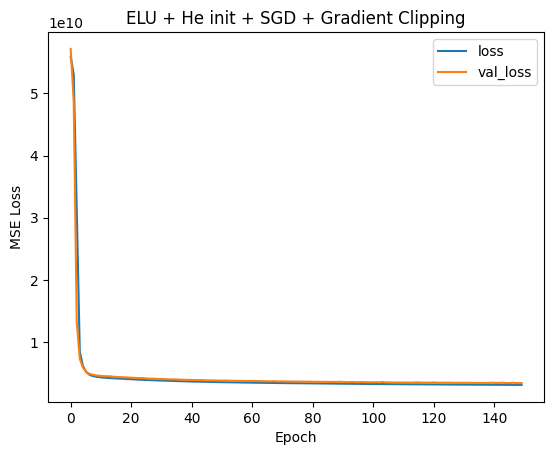

In [ ]:
pd.DataFrame(regressor.history).plot()
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.title('ELU + He init + SGD + Gradient Clipping')
plt.show()

In [ ]:
y_hat, rmse, ci = evaluate_model(regressor, X_test_t, y_test)


RMSE: $58,514
95% CI: [$55,917 , $61,000]


The network is now training! Gradient clipping was the key: by bounding the gradient norm
at each step, we prevent the runaway weight updates that made learning impossible.

Convergence is slow. This is expected: we are using plain SGD with
no momentum and no normalization. Now let's apply the full set of techniques to build a
well-tuned model.

<a id="full_stack"></a>

# Putting It All Together

We now combine all the techniques from the toolbox into a single model:

| Component | Choice | Reason |
|---|---|---|
| Activation | **ELU** | Smooth, no dying neurons, no special constraints |
| Initialisation | **He normal** | Paired with ELU to preserve activation variance |
| Normalisation | **BatchNorm** (after activation) | Reduces internal covariate shift, stabilises training |
| Optimizer | **Adam** | Fast convergence, robust defaults, no LR tuning needed |
| Regularization | **Dropout** ($p = 0.2$) | Prevents overfitting, architecturally explicit |
| Gradient clipping | **clip\_norm = 1.0** | Defensive; less critical with Adam + BN but costs nothing |

The architecture of each hidden layer is: **Linear → ELU → BatchNorm → Dropout**

In [ ]:
layers = [nn.Linear(n_features, 100), nn.ELU(alpha=1.0),
          nn.BatchNorm1d(100), nn.Dropout(p=0.2)]
for _ in range(5):
    layers.extend([nn.Linear(100, 100), nn.ELU(alpha=1.0),
                   nn.BatchNorm1d(100), nn.Dropout(p=0.2)])
layers.append(nn.Linear(100, 1))

model_net = nn.Sequential(*layers)
apply_he_normal(model_net)

regressor = NeuralNetRegressor(
    model=model_net,
    optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.001)
)

In [ ]:
trainer = make_trainer(max_epochs=150, patience=10, min_delta=1000.0, clip_norm=1.0)
trainer.fit(regressor, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/tizianaligorio/dev/deeplearning_notebooks/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing t

Epoch 1/150  loss: 55969894400  val_loss: 57541472256


Metric val_loss improved by 36524032.000 >= min_delta = 1000.0. New best score: 57504948224.000


Epoch 2/150  loss: 55938924544  val_loss: 57504948224


Metric val_loss improved by 67932160.000 >= min_delta = 1000.0. New best score: 57437016064.000


...

Epoch 136/150  loss: 3594333952  val_loss: 2944521216
Epoch 137/150  loss: 3498796032  val_loss: 2992511232


Metric val_loss improved by 220508416.000 >= min_delta = 1000.0. New best score: 2724012800.000


Epoch 138/150  loss: 3538707456  val_loss: 2724012800
Epoch 139/150  loss: 3584382208  val_loss: 2880651008
Epoch 140/150  loss: 3436719872  val_loss: 2888418048
Epoch 141/150  loss: 3468550656  val_loss: 2793052928
Epoch 142/150  loss: 3568943360  val_loss: 2798084352
Epoch 143/150  loss: 3467868928  val_loss: 2852876800
Epoch 144/150  loss: 3419878656  val_loss: 2932114688
Epoch 145/150  loss: 3428458240  val_loss: 2807058944
Epoch 146/150  loss: 3385412352  val_loss: 3095488000
Epoch 147/150  loss: 3313752320  val_loss: 2897195520


Monitored metric val_loss did not improve in the last 10 records. Best score: 2724012800.000. Signaling Trainer to stop.


Epoch 148/150  loss: 3404662272  val_loss: 2868795904


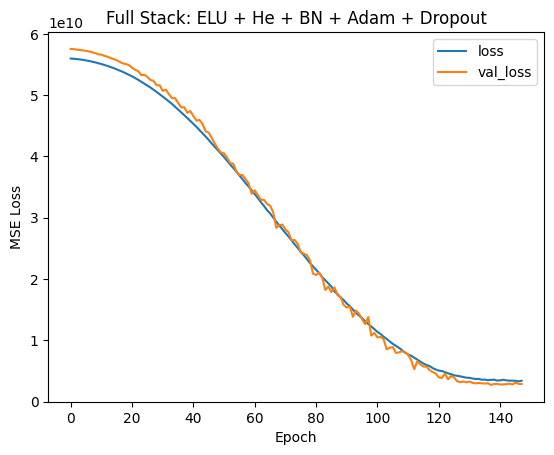

In [ ]:
pd.DataFrame(regressor.history).plot()
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.title('Full Stack: ELU + He + BN + Adam + Dropout')
plt.show()

<a id="evaluate"></a>

## Evaluate the Model
---

The model we trained is the one that achieved the lowest validation loss during training
(selected by `EarlyStopping`). We now evaluate it on the **test set** (data the model
has never seen) to get an unbiased estimate of its generalisation error. 

The RMSE (Root Mean Squared Error) measures the average prediction error in the same units as the target,
  dollars in this case. However, a single RMSE value computed on one test set cannot be fully trusted: a
  different random split might yield a slightly different number. To express how confident we are that the true
  generalisation error lies within a range, we compute a 95% confidence interval using a t-test on the squared
  errors:

  $$\text{RMSE} \in \left[\sqrt{\mu_{SE} - t_{0.975}\frac{\sigma_{SE}}{\sqrt{m}}},\ \sqrt{\mu_{SE} +
  t_{0.975}\frac{\sigma_{SE}}{\sqrt{m}}}\right]$$

  where $\mu_{SE}$ is the mean squared error, $\sigma_{SE}$ its standard deviation, and $m$ the number of test
  samples. Intuitively: if we were to repeat this evaluation many times on different samples from the same
  population, 95% of the resulting intervals would contain the true error. A narrow interval means our estimate
  is reliable; a wide one means we need more test data.

  <img src="images/t_interval.png" alt="confidence interval"> 

In [ ]:
y_hat, rmse, ci = evaluate_model(regressor, X_test_t, y_test)

RMSE: $53,140
95% CI: [$50,646 , $55,522]


We can report our confidence that the true generalisation RMSE lies within the interval above.

Here is how our model compares to previous results:

| Model | RMSE | 95% Confidence Interval |
|---|---|---|
| Linear Regression (Lab 1) | \$70,059 | — |
| Deep net + gradient clipping only | \$58,514 | [\$55,917 , \$61,000] |
| **Full stack (this model)** | \$53,140 | [\$50,646 , \$55,522] |

The full stack model demonstrates that combining the right techniques, not any single one alone, is
what allows deep networks to reach their potential. Each component plays a role:
gradient clipping makes learning possible, ELU and He init keep activations healthy,
BatchNorm stabilises the distributions across layers, Adam finds a good minimum quickly,
and Dropout reduces overfitting.